# Initalize libraries

## Import libraries

In [1]:
# general
import sys, os
import time
from os.path import join
from os import path
from importlib import reload
from getpass import getuser
from glob import glob
from tqdm.auto import tqdm
from multiprocessing import Pool
import shutil 
import gc

# Data
import xarray as xr
import h5py
import numpy as np
import imageio
from nexusformat.nexus import *
from PIL import Image

# Plotting
import matplotlib.pyplot as plt

# skimage
import skimage.morphology

# scipy
from scipy.ndimage import gaussian_filter
from scipy import stats
import scipy
from scipy.interpolate import griddata

# pyFAI
import pyFAI
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator
from pyFAI.detectors import Detector

# Self-written libraries
sys.path.append(join(os.getcwd(), "library"))
import helper_functions as helper
import mask_lib
import interactive
from interactive import cimshow
import phase_retrieval_core as PhR
import Phase_Retrieval_old_but_gold as phr_gold

plt.rcParams["figure.constrained_layout.use"] = True  # replaces plt.tight_layout


  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/gpfs/exfel/exp/SCS/202601/p010

In [2]:
# Is there a GPU?
try:
    # Cupy
    import cupy as cp
    import cupyx as cpx

    GPU = True

    print("GPU available")

    # Self-written library
    import CCI_core_cupy as cci
except:
    GPU = False
    import CCI_core as cci

    print("GPU unavailable")
parula_map = cci.parula_map()

GPU available


In [3]:
# interactive plotting
import ipywidgets

%matplotlib widget

# Auto formatting of cells
#%load_ext jupyter_black

In [4]:
facility = "PETRA" # Options: "SwissFEL", "MAXI"
PROPOSALID = 11024029
BEAMTIMEID = 11024029 # Proposal number
data_fname_prefix = "2606_XPCS"
USER = getuser()

# Facility specific loading functions
if facility == "PETRA":
    import PETRA_MaxP04_loading as loading
elif facility == "MAXI":
    import MAXI_loading as loading
elif facility == "SwissFEL":
    from sfdata import SFDataFiles, SFScanInfo, SFProcFile
    import Swiss_FEL_Loading as loading

    # Number or jobs for analysis
    NR_JOBS = 32
elif facility == "MAXIV":
    import MAXI_loading as loading

BASEFOLDER = "/asap3/petra3/gpfs/p04/2026/data/%d"%(PROPOSALID)
DATAFOLDER = join(BASEFOLDER,"raw")

print("Raw Datafolder is: %s"%DATAFOLDER)

# Load dictionary for keys etc
mnemonics = loading.load_mnemonics()

Raw Datafolder is: /asap3/petra3/gpfs/p04/2026/data/11024029/raw


### Loading data

In [5]:
def generate_filename(scan_nr: int):
    """
    Generates filename of the given scan id

    Parameter
    =========
    scan_nr : number identifier (id) of the given scan

    Output
    ======
    filename : str
        full generated filename
    ======
    author: ck 2025
    """
    return join(DATAFOLDER, f"{data_fname_prefix}_{scan_nr:05d}.nxs")

def get_marana_filenames(scan_nr: int, file_indices = None):
    """
    Generates filename of the given scan id

    Parameter
    =========
    scan_nr : number identifier (id) of the given scan

    Output
    ======
    filename : str
        full generated filename
    ======
    author: ck 2025
    """

    scan_count = load_key(scan_nr, "/scan/data/point_nb")
    if np.ndim(scan_count) == 0:
        scan_count = 1
    elif np.ndim(scan_count) > 0:
        scan_count = scan_count.shape[0]

    #this does not work anymore since we are sampling with 200 frames per file -> os.listdir....
    
    names = os.listdir(join(DATAFOLDER, f"{data_fname_prefix}_{scan_nr:05d}","marana"))
    names = [name for name in names if name[-2:]=="nx"]
    fnames = np.array([join(DATAFOLDER, f"{data_fname_prefix}_{scan_nr:05d}","marana",name) for name in names])
    fnames = np.array(sorted(fnames))
    files = []
    counter =  0
    for file in fnames:
        with h5py.File(file, "r") as f:
            if len(f["/entry/instrument/detector/timestamps"][()]) > 3:
                files.append(file)
            else:
                counter+=1
    if counter > 0:
        print(f"{counter} Files have less then 3 images and where not loaded")
    fnames = np.array(files)
    if file_indices is not None:
        fnames = fnames[file_indices]
    
        if type(fnames) == str:
            fnames = np.array([fnames])

    
    return fnames

def load_data(scan_id, keypath=mnemonics["collection"], keys=None):
    """
    Load data of all specified keys from keypath

    Parameter
    =========
    scan_id : int
        experimental identifier of scan
    keypath : str
        path of nexus file tree to relevant data field
    keys : str or list of strings
        keys to load from keypath

    Output
    ======
    data : dict
        data dictionary of keys
    ======
    author: ck 2024
    """

    # Generate filename from scan_id
    fname = generate_filename(scan_id)

    # load data with basic loading function
    data = loading.load_data(fname, keypath, keys=keys)

    return data


def load_key(scan_id, key):
    """
    Load any kind of data specified by key (path)

    Parameter
    =========
    scan_id : int
        experimental identifier of scan
    key : str
        key path of nexus file tree to relevant data field

    Output
    ======
    data : dict
        data dictionaray on single key
    ======
    author: ck 2024
    """
    # Generate filename from scan_id
    fname = generate_filename(scan_id)

    # load data with basic loading function
    data = loading.load_key(fname, key)

    return data

## Loading images

In [6]:
def load_images(im_id, file_indices = None):
    """
    Loads images for a given scan id

    Parameter
    =========
    im_id : int
        experimental identifier of image scan

    Output
    ======
    images : array
        stack of all images the correspond to the id
    ======
    author: ck 2024
    """

    # Generate filesnames
    fnames  = get_marana_filenames(im_id, file_indices = file_indices)

    # load data
    images = [loading.load_key(fname,mnemonics["nx_marana"]) for fname in tqdm(fnames)]
    images = np.stack(images)
    
    return images.astype("float32")

### Loading image procedure

In [7]:
# Full image loading procedure
def load_processing(im_id, file_indices = None, binning = 1, crop = None):
    """
    Loads images, averaging of two individual images (scans in tango consist of two images),
    padding to square shape, Additional cropping (optional)
    """

    # Load data
    images = load_images(im_id, file_indices = file_indices)

    # Optional cropping
    if crop is not None:
        images = images[..., :crop, :crop]

    # Binning
    if binning > 1:
        images = helper.binning(images, binning)

    # Average over all images
    if images.ndim == 4:
        image = np.mean(images, axis=(0, 1))
    elif images.ndim == 3:
        image = np.mean(images, axis=(0))
    elif images.ndim == 2:
        image = images.copy()
    images = np.stack(images)
    
    return image, images

### Loading, saving fth & cdi data

In [8]:
# Saving of log files for fth and cdi recos
def save_fth_h5():
    # Save h5
    data = {}
    data["im_id"] = im_id
    data["topo_id"] = topo_id
    data["topo_centered"] = topo_c
    data["im_centered"] = im_c
    data["holo"] = holo
    data["recon"] = recon
    data["factor"] = factor
    data["offset"] = offset
    data["center"] = center
    data["roi"] = roi
    data["prop_dist"] = prop_dist
    data["phase"] = phase
    data["mask_bs"] = mask_pixel_smooth
    data["bs_smoothing"] = bs_smoothing
    data["experimental_setup"] = experimental_setup

    filename = join(
        folder_general, "Logs", "Data_ImId_%s_RefId_%s_%s" % (im_id, topo_id, USER)
    )
    print("Now Saving: %s" % filename)
    cci.create_hdf5(data, filename)


def save_cdi_h5():
    # Save h5
    data = {}
    data["im_id"] = im_id
    data["topo_id"] = topo_id
    data["pos"] = pos
    data["neg"] = neg
    data["factor"] = factor
    data["offset"] = offset
    data["center"] = center
    data["roi"] = roi
    data["prop_dist"] = prop_dist_cdi
    data["phase"] = phase_cdi
    data["mask_bs"] = mask_bs_cdi
    data["supportmask"] = supportmask
    data["mask_pixel"] = mask_pixel
    data["p_pc"] = p_pc
    data["n_pc"] = n_pc
    data["experimental_setup"] = experimental_setup

    filename = join(
        folder_general,
        "Logs",
        "Data_ImId_%s_RefId_%s_cdi_%s" % (im_id, topo_id, USER),
    )
    print("Now Saving: %s" % filename)
    cci.create_hdf5(data, filename)
    return

## Worker which performs complete fth reconstruction process

In [9]:
def worker(image, topo, Norm = True):
    # Centering
    shift_c = np.array(topo.shape) / 2 - center
    topo_c = cci.shift_image(topo, shift_c)
    im_c = cci.shift_image(image, shift_c)

    ## Image registration
    shift = cci.image_registration(
       im_c[roi_im_reg],
        topo_c[roi_im_reg],
     method="phase_cross_correlation",
    )
    print("Relative shift is: %s" % shift)

    # Correct relative drift
    if sum(abs(shift)) > 0.05:
        im_c = cci.shift_image(im_c, -shift)
    
    if Norm:
        # Get scaling factor and offset
        factor, offset = cci.dyn_factor(
            im_c * (1 - mask_pixel),
            topo_c * (1 - mask_pixel),
            method="correlation",
            verbose=False,
            plot=False,
        )
    else:
        factor = 1
        offset = 0

    # Calculate differences (magnetic) and sums (topographc) contrast holograms.
    # _c: centered, without beamstop, _b: centered, with beamstop
    diff_c = im_c / factor - topo_c - offset
    sum_c = im_c / factor + topo_c - offset

    # Reconstruct
    recon = cci.reconstruct(
        cci.propagate(diff_c, prop_dist * 1e-6, experimental_setup=experimental_setup)
        * np.exp(1j * phase)
    )

    # worker dictionary
    worker_dict = {}
    worker_dict["center"] = center
    worker_dict["topo_c"] = topo_c
    worker_dict["im_c"] = im_c
    worker_dict["recon"] = recon
    worker_dict["factor"] = factor
    worker_dict["offset"] = offset
    worker_dict["shift"] = shift
    worker_dict["diff_c"] = diff_c
    worker_dict["sum_c"] = sum_c
    worker_dict["mask_pixel_smooth"] = mask_pixel_smooth
    worker_dict["mask_pixel"] = mask_pixel

    return worker_dict

## Other

In [10]:
# Setup
phase_cdi = 0
prop_dist_cdi = 0

In [11]:
def get_title(data_key, im_id, topo_id, CDI=False, Framenumber= None):
    # Rotation in title
    if data_key is not None:
        data = load_key(im_id,mnemonics[data_key])

    if CDI is False:
        mode = "FTH"
    elif CDI is True:
        mode = "CDI"

    if data_key == "magOOP":
        title = "Image %s - %s @%.3f A (OOP) - %s " % (
            im_id,
            topo_id,
            data,
            mode,
        )
    elif data_key == "magIP":
        title = "Image %s - %s @%.3f A (IP) - %s " % (
            im_id,
            topo_id,
            data,
            mode,
        )

    elif data_key == "energy":
        title = "Image %s - %s @%.3f eV - %s " % (
            im_id,
            topo_id,
            data,
            mode,
        )
    else:
        title = "Image %s - %s %s " % (
            im_id,
            topo_id,
            mode,
        )
    return title


In [12]:
def plot_recon(recon, title, rmin = 1, rmax = 99, scale_mask=None):
    if scale_mask is None:
        scale_mask = np.ones(recon.shape)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    tmp = np.real(recon) * scale_mask
    vmin, vmax = np.nanpercentile(tmp[tmp != 0], (rmin, rmax))
    t_im1 = ax[0].imshow(np.real(recon), vmin=vmin, vmax=vmax, cmap="gray")
    ax[0].set_title("Real")
    plt.colorbar(t_im1, ax=ax[0], aspect=50)

    tmp = np.imag(recon) * scale_mask
    vmin, vmax = np.nanpercentile(tmp[tmp != 0], (rmin, rmax))
    t_im2 = ax[1].imshow(np.imag(recon), vmin=vmin, vmax=vmax, cmap="gray")
    ax[1].set_title("Imag")
    plt.colorbar(t_im2, ax=ax[1], aspect=50)

In [13]:
def save_gif(output_path, image_path_list, fps=3 ):
    writer = imageio.get_writer(output_path, format="GIF-PIL", fps=fps)
    for im in tqdm(image_path_list):
        writer.append_data(imageio.imread(im))
    writer.close()

# Experimental Details

In [14]:
# Dict with most basic experimental parameter
camera_type = "cmos"

# Get detector pixel size, CMOS: 11 um, Sophia CCD: 13.5 um, Other CCD: 20µm
if camera_type == "cmos":
    px_size = 11e-6
elif camera_type == "ccd":
    px_size = 20e-6

experimental_setup = {
    "ccd_dist": 0.17,  # ccd to sample distance
    "px_size": px_size,  # 
    "binning": 1,  # Camera binning
    "oversaturation": 2**16,  # Pixel saturation threshold
}

# Setup for azimuthal integrator
detector = Detector(
    experimental_setup["binning"] * experimental_setup["px_size"],
    experimental_setup["binning"] * experimental_setup["px_size"],
)

# General saving folder and log folder
folder_general = join(BASEFOLDER, "processed")
helper.create_folder(folder_general)

print("Output Folder: %s" % folder_general)

Output Folder: /asap3/petra3/gpfs/p04/2026/data/11024029/processed


# Load images

Start by loading the images: image of interest (im), reference of charge scattering (topo), any kind of dark image (dark)

We estalished the following convention: Difference Hologram which contains only the magnetic scattering will be calculated according to:

$Diff = \frac{Image}{factor} - Topo$,

where the factor is used for intensity scaling. In Case that you recorded scans of the same magnetic state with both helicities, use the image with negative helicity as topo and the one with positive helicity as image

In [15]:
# Define scan id of each image or as list for multiple scans that will be averaged
im_id =  4# single helicity mode: image with magnetic contrast, double helicity: pos+, 4416d, 4417
topo_id = 4#single helicity mode: image without magnetic contrast, double helicity: neg

# Camera background image
dark_id_im = 4
dark_id_topo = dark_id_im

# Optional for CMOS data
file_indices_im = None #np.arange(50) # Load specific image stack, None means all stacks
file_indices_topo = None # Load specific topo stack, None means als

# Which other meta data to load
scan_axis = "magIP"

# Load energy and add to experimental setup
experimental_setup["energy"] = load_key(im_id, mnemonics["energy"])
experimental_setup["lambda"] = helper.photon_energy_wavelength(
    experimental_setup["energy"], input_unit="eV"
)

print("Image Id: %s" % im_id)
print("Topo Id: %s" % topo_id)
print("Dark Id Im: %s" % dark_id_im)
print("Dark Id Topo: %s" % dark_id_topo)

Image Id: 4
Topo Id: 4
Dark Id Im: 4
Dark Id Topo: 4




## Load image of interest

  0%|          | 0/2 [00:00<?, ?it/s]

interactive(children=(FloatRangeSlider(value=(1.0453228950500488, 1.4712917804718018), description='contrast',…

Text(0.5, 1.0, 'Image')

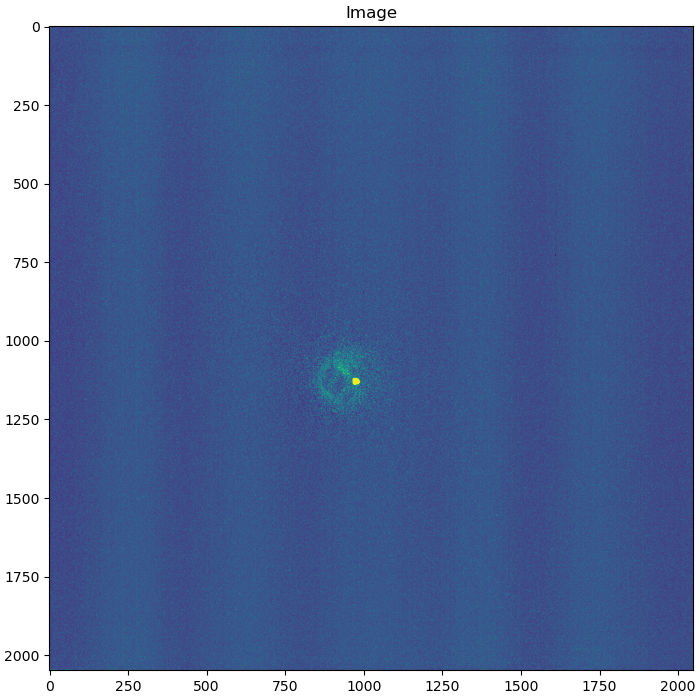

In [16]:
# Load image
if isinstance(im_id,list):
    images = np.stack([load_processing(idx,file_indices = file_indices_im)[0] for idx in im_id])
    image = np.mean(images,axis=0)
    print("list")
else:
    image, images = load_processing(im_id, file_indices = file_indices_im)
    
# Plot
fig, ax = cimshow(helper.log_clip(image))
#fig, ax = cimshow(image)
ax.set_title("Image")

## Load topo data set and average

  0%|          | 0/2 [00:00<?, ?it/s]

interactive(children=(FloatRangeSlider(value=(1.0453228950500488, 1.4712917804718018), description='contrast',…

Text(0.5, 1.0, 'Topo')

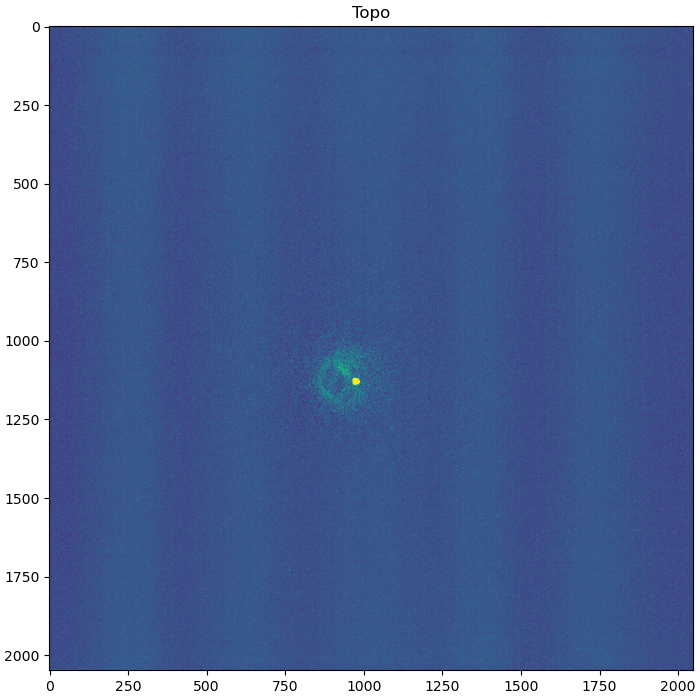

In [18]:
# Load topo
if isinstance(topo_id,list):
    topos = np.stack([load_processing(idx)[0] for idx in topo_id])
    topo = np.mean(images,axis=0)
else:
    topo, topos = load_processing(topo_id, file_indices = file_indices_topo)

# Plot
fig, ax = cimshow(helper.log_clip(topo))
ax.set_title("Topo")

## Load dark image

  0%|          | 0/2 [00:00<?, ?it/s]

interactive(children=(FloatRangeSlider(value=(97.94999694824219, 116.44999694824219), description='contrast', …

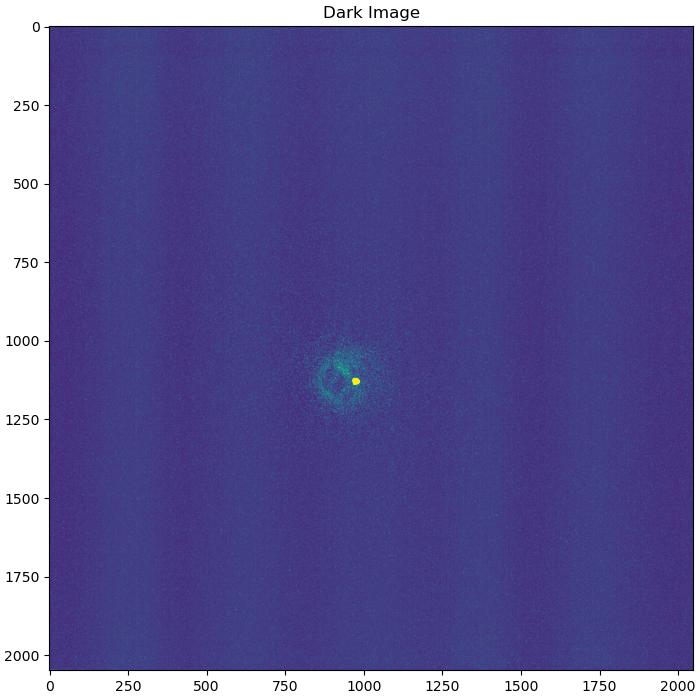

In [19]:
# Load image
if dark_id_im is not None:
    dark, darks = load_processing(dark_id_im, file_indices = None, crop=None)
    image = image - dark

    # Plot
    fig, ax = cimshow(dark)
    ax.set_title("Dark Image")

if dark_id_topo is not None:
    if dark_id_topo != dark_id_im:
        dark, _ = load_processing(dark_id_topo, crop=None) 
        
        # Plot
        fig, ax = cimshow(dark)
        ax.set_title("Dark Topo")
        
    topo = topo - dark

interactive(children=(FloatRangeSlider(value=(0.0, 0.0), description='contrast', layout=Layout(width='500px'),…

interactive(children=(IntSlider(value=0, description='nr', max=1), Output()), _dom_classes=('widget-interact',…

Text(0.5, 1.0, 'Image, Topo')

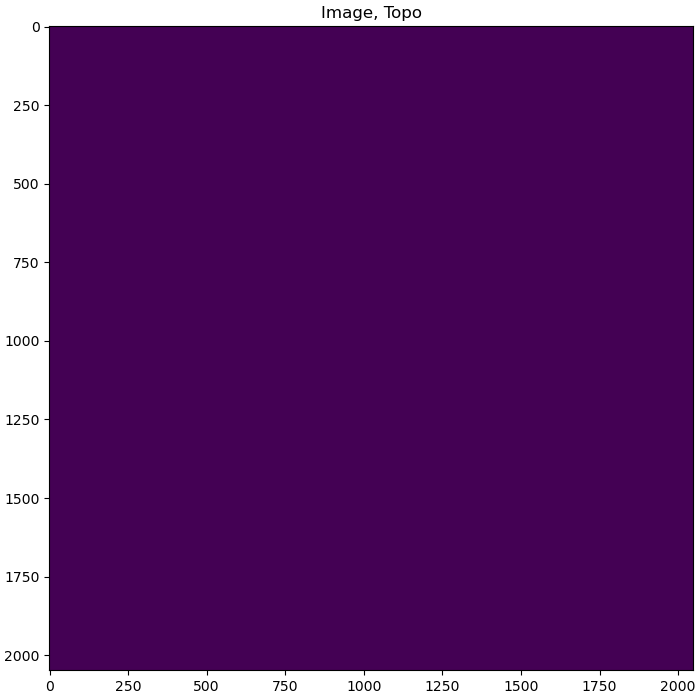

In [20]:
fig, ax = cimshow([image,topo])
ax.set_title("Image, Topo")

# Center holograms

* Find center of the hologram to get a well-defined q-space. 
* Create smooth mask for beamstop or overexposed areas in direct beam

## Basic widget to find center

Try to **align** the circles to the **center of the scattering pattern**. Care! Position of beamstop might be misleading and not represent the actual center of the hologram. Circles are just a guide to eye and will not be used otherwise.

In [ ]:
# Find center position via widget
c0, c1 = [962, 1035]  # initial values
ic = interactive.InteractiveCenter(topo, c0=c0, c1=c1)

In [ ]:
# Get center positions
center = [ic.c0, ic.c1]
#center = [961, 1035]
print(f"Center:", center)

## Azimuthal integrator widget for finetuning
More of an "expert widget" which works very well for alignment if you have an Airy Pattern as a scattering image. PyFai transforms images from carthesian detector coordinate system into polar coordinate system with angle `phi` and radial distance `q` as axis (azimuthal transformation). The center of the coordinate system will be defined in the azimuthal integrator class and must not necessarily represents the center coordinates of your image array. If the center is set correctly, all rings of the Airy pattern will be transformed into a straight line in the I(q,chi)-plot as rings appear at a given q for all angles chi.

In [ ]:
# Setup azimuthal integrator for virtual geometry
ai = AzimuthalIntegrator(
    dist=experimental_setup["ccd_dist"],
    detector=detector,
    wavelength=experimental_setup["lambda"],
    poni1=center[0]
    * experimental_setup["px_size"]
    * experimental_setup["binning"],  # y (vertical)
    poni2=center[1]
    * experimental_setup["px_size"]
    * experimental_setup["binning"],  # x (horizontal)
)

In [ ]:
# Not the widget, just for double checking to find correct radial range for plotting
q_range_plotting = (0.01, 0.05)

# Perform azimuthal transformation
I_t, q_t, phi_t = ai.integrate2d(
    helper.log_clip(topo),
    500,  # number of points for phi
    radial_range=q_range_plotting,  # relevant q-range
    unit="q_nm^-1",
    correctSolidAngle=False,
    method="BBox",
)
# Combine in an xarray for plotting
az2d = xr.DataArray(I_t, dims=("phi", "q"), coords={"q": q_t, "phi": phi_t})

# Plot
fig, ax = plt.subplots()
#mi, ma = np.percentile(I_t, [0.1, 99.9])
az2d.plot.imshow(ax=ax)#, vmin=mi, vmax=ma)
plt.title(f"Azimuthal integration")

In [ ]:
# The widget
aic = interactive.AzimuthalIntegrationCenter(
    helper.log_clip(topo),
    # image,
    ai,
    c0=center[0],
    c1=center[1],
    im_data_range=[1, 98],
    radial_range=q_range_plotting,
    qlines=[100, 110],
)

In [ ]:
# Get center positions from widget
center = [aic.c0, aic.c1]
print(f"Center:", center)

## Here: Centering of image hologram

In [ ]:
# Apply to topo and image
shift_c = np.array(image.shape) / 2 - center
im_c = cci.shift_image(image, shift_c)
topo_c = cci.shift_image(topo, shift_c)  # centered image

# Image Registration

Relative drift between data holograms and their corresponding topo holograms is calculated by image registration algorithm. Necessary to get well defined difference hologram. The reference is always the static background image (topo).

## Set Alignment ROI 

Set a region of interest (ROI) of reference (topo) use for image registration is performed. Can include beamstop when beamstop mask was defined.

How to use:
1. Zoom into the image and adjust your FOV until you are satisfied.
2. Save the axes coordinates.

In [ ]:
fig, ax = cimshow(im_c)
ax.set_title("Don't include the beamstop as this will misdirect the algorithm")

In [ ]:
# Takes start and end of x and y axis
x1, x2 = ax.get_xlim()
y2, y1 = ax.get_ylim()
roi_im_reg = np.array([y1, y2, x1, x2]).astype(int)
roi_im_reg = [ 931, 1137, 1134, 1301]
roi_im_reg_s = np.s_[roi_im_reg[0] : roi_im_reg[1], roi_im_reg[2] : roi_im_reg[3]]

print(f"Image registration roi:", roi_im_reg)

## Calculate drift of images

In [ ]:
shift = cci.image_registration(
    im_c[roi_im_reg_s],
    topo_c[roi_im_reg_s],
    method="dipy",
)
print("Relative shift is: %s" % shift)

In [ ]:
# Define shift manually for comparison
tmp_shift = [1, 2]

# Loop over shifts
temp_diff = np.zeros((3, im_c.shape[0], im_c.shape[1]))
shifts = [
    [0, 0],
    tmp_shift,
    -shift,
]
for i, tshift in enumerate(shifts):
    temp = cci.shift_image(im_c, tshift)
    temp_factor = cci.dyn_factor(temp, topo_c, method="correlation")
    temp_diff[i] = temp - temp_factor[0] * topo_c

# Plots for comparision
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12, 4))
mi, ma = np.percentile(temp_diff[0], [0.1, 99.9])
ax[0].imshow(temp_diff[0], vmin=mi, vmax=ma)
ax[0].set_title("Zero shift")
mi, ma = np.percentile(temp_diff[2], [0.1, 99.9])
ax[1].imshow(temp_diff[2], vmin=mi, vmax=ma)
ax[1].set_title("Auto shift: %s px" % np.round(shifts[2], 2))
mi, ma = np.percentile(temp_diff[1], [0.1, 99.9])
ax[2].imshow(temp_diff[1], vmin=mi, vmax=ma)
ax[2].set_title("Manual shift: %s px" % shifts[1])

## Correct drift of image

In [ ]:
# Correct relative drift
if sum(abs(shift)) > 100:
    im_c = cci.shift_image(im_c, -shift)

# Plot original and shifted holos
mi, ma = np.percentile(np.real(topo_c[topo_c != 0]), (0.1, 99))
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
ax[0].imshow(np.real(topo), cmap="viridis", vmin=mi, vmax=ma)
ax[0].set_title("Uncentered topo")
ax[1].imshow(np.real(topo_c), cmap="viridis", vmin=mi, vmax=ma)
ax[1].set_title("Centered topo with beamstop")

# Add circles with different radi r
tmp = np.array(image.shape) / 2
for r in np.arange(50, 200, 25):
    ax[0].add_artist(plt.Circle((tmp[1], tmp[0]), r, fill=None, ec="red"))
    ax[1].add_artist(plt.Circle((tmp[1], tmp[0]), r, fill=None, ec="red"))

# Create beamstops

We want to cover the beamstop with a smooth circle to cover its sharp edges as these would create ringing-like artifacts in the reconstruction plane. Make it only as large as necessary to keep as much information as possible.

## Manual masking of beamstop wires

Just mask the beamstop wires, broken pixels, etc. 

In [ ]:
#poly_mask = interactive.draw_polygon_mask(helper.log_clip(im_c))
poly_mask = interactive.draw_polygon_mask(im_c)

In [ ]:
# Take poly coordinates and mask from widget
p_coord = poly_mask.get_vertice_coordinates()
mask_draw = poly_mask.full_mask.astype(int)

print("Copy these coordinates into the 'load_poly_coordinates()' function:")
print(p_coord)

# Plot image with beamstop and valid pixel mask
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9, 3))
mi, ma = np.percentile(im_c * (1 - mask_draw), [0.1, 99.9])
ax[0].imshow(im_c * (1 - mask_draw), cmap="viridis", vmin=mi, vmax=ma)
ax[0].set_title("Image * (1-mask_draw)")

mi, ma = np.percentile(im_c * mask_draw, [0.1, 99.9])
ax[1].imshow(im_c * mask_draw, vmin=mi, vmax=ma)
ax[1].set_title("Image * mask_draw")

ax[2].imshow(1 - mask_draw)
ax[2].set_title("1 - mask_draw")

In [ ]:
def load_poly_coordinates():
    """
    Dictionary that stores polygon corner coordinates of all drawn masks
    Example: How to add masks with name "test":
    mask_coordinates["test"] = copy coordinates from above
    """
    mask_coordinates = dict()
    mask_coordinates["bs_fixed"] = [[(1018.2, 980.3), (1011.9, 982.6), (1004.0, 985.5), (997.4, 990.4), (990.5, 997.3), (986.5, 1003.2), (983.4, 1009.4), (982.0, 1016.5), (982.0, 1022.4), (982.0, 1033.1), (984.4, 1041.2), (987.7, 1048.5), (992.7, 1054.7), (1001.9, 1061.8), (1009.0, 1066.5), (1021.1, 1068.9), (1037.0, 1067.9), (1046.7, 1064.4), (1056.6, 1056.6), (1065.7, 1046.4), (1065.7, 1046.6), (1070.9, 1031.7), (1069.7, 1017.9), (1066.1, 1004.4), (1057.6, 993.3), (1048.1, 985.9), (1036.0, 980.3)], [(986.4, 1013.0), (973.0, 1015.9), (968.8, 1017.6), (966.3, 1020.1), (962.5, 1020.1), (959.6, 1025.2), (955.4, 1027.3), (951.2, 1024.7), (946.1, 1024.7), (941.9, 1028.5), (940.7, 1034.4), (939.4, 1038.2), (915.9, 1048.7), (911.7, 1047.0), (908.0, 1046.1), (905.0, 1049.9), (903.8, 1052.9), (897.5, 1052.9), (891.2, 1056.6), (891.6, 1060.8), (863.1, 1077.6), (855.9, 1075.5), (851.7, 1076.8), (850.5, 1080.5), (848.8, 1083.5), (843.3, 1083.1), (821.1, 1094.0), (811.5, 1101.1), (801.2, 1105.2), (793.0, 1112.1), (535.8, 1244.7), (530.8, 1253.1), (792.6, 1120.1), (833.9, 1098.4), (853.7, 1087.1), (859.5, 1087.5), (864.1, 1081.7), (894.3, 1064.9), (900.6, 1065.3), (905.7, 1060.7), (908.6, 1057.7), (914.1, 1058.6), (919.9, 1051.5), (944.3, 1040.5), (952.2, 1040.1), (958.5, 1030.5), (987.1, 1017.9)], [(1042.6, 985.7), (1193.9, 906.9), (1338.8, 828.1), (1458.3, 759.8), (1453.3, 758.0), (1318.6, 832.4), (1248.9, 869.6), (1134.0, 931.4), (1075.0, 961.2), (1038.4, 982.5)], [(1042.6, 985.7), (1193.9, 906.9), (1338.8, 828.1), (1458.3, 759.8), (1453.3, 758.0), (1318.6, 832.4), (1248.9, 869.6), (1134.0, 931.4), (1075.0, 961.2), (1038.4, 982.5)]]
    mask_coordinates["membrane_s2604d_D3"] = [[(1030.2, 908.7), (1017.0, 909.1), (1018.3, 922.8), (1031.1, 922.7)]]
    mask_coordinates["camera_dmg"] = [[(1100.3, 1199.8), (1100.5, 1214.1), (1115.1, 1214.1), (1113.4, 1198.1)]]
    mask_coordinates["membranes_s2604d_B1"] = [[(1029.0, 1115.4), (1018.7, 1116.0), (1019.2, 1130.9), (1028.8, 1130.6)]]
    mask_coordinates["membranes_s2604d_D1"] = [[(1018.5, 909.2), (1018.9, 922.8), (1031.9, 923.1), (1030.1, 909.0)]]
    mask_coordinates["newmembranedmg1504"] = [[(1033.9, 102.0), (1018.4, 242.1), (1013.6, 284.2), (1061.4, 287.0), (1063.4, 252.0), (1162.4, 260.8), (1175.6, 116.3)]]
    mask_coordinates["2newmembranedmg1504"]= [[(1036.5, -0.4), (1036.8, 18.4), (1174.5, 5.4), (1174.5, 0.1)]]
    return mask_coordinates

In [ ]:
# Which drawn masks do you want to load? You can combine multiple masks from
# load_poly_coordinates(). Just add names of mask as strings to list like
# ["bs_small","bs_medium"]
polygon_names = ["bs_fixed","camera_dmg"]
mask_draw = mask_lib.load_poly_masks(
    experimental_setup["binning"] * image.shape,
    load_poly_coordinates(),
    polygon_names,
)

#mask_draw = cci.shift_image(mask_draw,[0,-8])

# Plot image with beamstop and valid pixel mask
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9, 3))
mi, ma = np.percentile(im_c * (1 - mask_draw), [0.1, 99.9])
ax[0].imshow(im_c * (1 - mask_draw), cmap="viridis", vmin=mi, vmax=ma)
ax[0].set_title("Image * (1-mask_draw)")

# mi, ma = np.percentile(im_c * mask_draw, [0.1, 90])
ax[1].imshow(im_c * mask_draw, vmin=mi, vmax=ma)
ax[1].set_title("Image * mask_draw")

ax[2].imshow(1 - mask_draw)
ax[2].set_title("1 - mask_draw")

## Finetuning of mask position

In [ ]:
# Use widget to shift and expand or shrink the mask
ss_mask = interactive.Shift_Scale_Mask(im_c, mask_draw, shift=[-4,-3], scale=1)

In [ ]:
# Take mask, shift and scaling from widget
mask_draw, mask_shift, mask_scale = ss_mask.get_mask()

## Overview beamstops
Verify good beamstop alignment

In [ ]:
# Smoothing of beamstop mask
bs_smoothing = 2

# Add circular beamstop mask
mask_im = mask_draw.copy()
mask_topo = mask_draw.copy()

# Mask over-saturated pixel
mask_im = mask_im + (im_c > experimental_setup["oversaturation"])
mask_topo = mask_topo + (topo_c > experimental_setup["oversaturation"])

# Combine both
mask_pixel = mask_im + mask_topo
mask_pixel[mask_pixel > 1] = 1

# Create smooth mask for FTH reconstructions
footprint = skimage.morphology.disk(3 * bs_smoothing)
mask_pixel_smooth = skimage.morphology.dilation(mask_pixel, footprint)
mask_pixel_smooth = gaussian_filter(mask_pixel_smooth, bs_smoothing)

# Plot both
fig, ax = plt.subplots(2, 4, figsize=(10, 5), sharex=True, sharey=True)
mi, ma = np.percentile(im_c, [1, 99.9])
ax[0, 0].imshow(im_c, vmin=mi, vmax=ma)
ax[0, 0].set_title("Image")
mi, ma = np.percentile(im_c * mask_im, [1, 99.99])
ax[0, 1].imshow(im_c * mask_im, vmin=mi, vmax=ma)
ax[0, 1].set_title("Image*mask")
mi, ma = np.percentile(im_c * (1 - mask_im), [0.1, 99.9])
ax[0, 2].imshow(im_c * (1 - mask_im), vmin=mi, vmax=ma)
ax[0, 2].set_title("Image*(1-mask)")
ax[0, 3].imshow(mask_pixel_smooth)
ax[0, 3].set_title("Combined Mask")

mi, ma = np.percentile(topo_c, [1, 99.9])
ax[1, 0].imshow(topo_c, vmin=mi, vmax=ma)
ax[1, 0].set_title("Topo")
mi, ma = np.percentile(topo_c * mask_im, [1, 99.99])
ax[1, 1].imshow(topo_c * mask_topo, vmin=mi, vmax=ma)
ax[1, 1].set_title("Topo*mask")
mi, ma = np.percentile(topo_c * (1 - mask_topo), [0.1, 99.9])
ax[1, 2].imshow(topo_c * (1 - mask_topo), vmin=mi, vmax=ma)
ax[1, 2].set_title("topo*(1-mask)")
mi, ma = np.percentile((im_c - topo_c) * (1 - mask_pixel_smooth), [0.1, 99.9])
ax[1, 3].imshow((im_c - topo_c) * (1 - mask_pixel_smooth), vmin=mi, vmax=ma)
ax[1, 3].set_title("Image-Topo")

# Here: Calculate difference holograms

You can see the reconstrution of the magnetization only after subtracting the large background that you get from the diffraction on the circular object aperture (Airy Pattern). This might require a scaling factor to correct intensity changes between the hologram and the topo. Scaling factor will be determined automatically by a linear fit. If the fit seems off, there might be an issue with the data

In [ ]:
# Get scaling factor and offset
factor, offset = cci.dyn_factor(
    im_c * (1 - mask_pixel),
    topo_c * (1 - mask_pixel),
    method="correlation",
    verbose=True,
    plot=True,
)
#factor = 1
#offset = 0
# Calculate differences (magnetic) and sums (topographc) contrast holograms.
# _c: centered, without beamstop, _b: centered, with beamstop
diff_c = im_c / factor - topo_c - offset
sum_c = im_c / factor + topo_c - offset

In [ ]:
# Plot an example of the difference or sum hologram
tmp = diff_c * (1 - mask_pixel_smooth)
#tmp = np.sign(diff_c)*np.log10(np.abs(diff_c))

fig, ax = cimshow(tmp, cmap = "viridis")
ax.set_title(f" Diff Id %s - %s" % (im_id, topo_id))

#fig, ax = cimshow(sum_c* (1 - mask_pixel_smooth))
#ax.set_title(f" Sum Id %d" % im_id)

# Reconstruct Diff Holos (FTH)

Reconstruct the hologram.

0. If you are doing heraldo, determine the rotation angle of the hologram
1. Choose a region of interest (ROI) which means selecting one reconstruction from the reconstruction plane.
2. Propagate the image and shift the phase for maximal contrast and sharpness in your ROI

## Set Patterson Map ROI

Choose the reconstructions as the ROI.

1. Zoom into the image and adjust your FOV until you are satisfied.
2. Save the axes coordinates.

In [ ]:
# Choose contrast mode
# diff_c: magnetic contrast only
# sum_c: topographic contrast only
holo = diff_c * (1 - mask_pixel_smooth)
#holo = im_c * (1 - mask_pixel_smooth)
#holo = topo_c * (1 - mask_pixel_smooth)
#holo = sum_c * (1 - mask_pixel_smooth)

tmp = cci.reconstruct(holo)

fig, ax = cimshow(np.real(tmp), cmap="gray")

In [ ]:
# Execute to get roi
x1, x2 = ax.get_xlim()
y2, y1 = ax.get_ylim()
roi = np.array([y1, y2, x1, x2]).astype(int)  # ystart, ystop, xstart, xstop
#roi = [1050, 1112,  933,  999]
#roi = [924, 991, 924, 992]
#roi = [741, 910, 758, 919]
#roi = [ 663,  830,  974, 1136]
#roi = [ 976, 1138, 1205, 1370]

roi_s = np.s_[roi[0] : roi[1], roi[2] : roi[3]]
print(f"Roi Reco:{roi}")

## Tune propagation and phase
Focus the image by tuning the propagation distance. This really works like focussing in a microscope.
Phase slider will move contrast between real and imaginary part. Usually we use the phase which maximizes the contrast in the real part.

In [ ]:
# Widget
holo = sum_c * (1 - mask_pixel_smooth)
holo = diff_c * (1 - mask_pixel_smooth)

slider_prop, slider_phase = interactive.propagate_phase(
    holo,
    roi_s,
    phase=-0.01,  # Initial value
    prop_dist=-2.91,  # Initial value
    experimental_setup=experimental_setup,
    scale=(.1, 99.9),
)

In [ ]:
# Read prop dist and phase from widget
prop_dist = slider_prop.value
phase = slider_phase.value

print(f"Propagation distance: %0.2f" % prop_dist)
print(f"Phase: %0.2f" % phase)

## Save reconstruction

Save png files of the images and a h5 file containing all important variables

In [ ]:
# Create plot
holo = diff_c * (1 - mask_pixel_smooth)

# Reconstruct
recon = cci.reconstruct(
        cci.propagate(holo, prop_dist * 1e-6, experimental_setup=experimental_setup)
        * np.exp(1j * phase)
    )

# Create plot
title = get_title("energy", im_id, topo_id)
plot_recon(recon[roi_s], title)

# Save images
fname = join(
    folder_general,
    "Recon_ImId_%s_RefId_%s_%s.png" % (im_id, topo_id, USER),
)
print("Saving: %s" % fname)
plt.savefig(fname, bbox_inches="tight", transparent=False)

# Save hdf5 file
#save_fth_h5()

In [ ]:
# Closes all existing plots
plt.close("all")

# Batch processing FTH (update!)

# CDI Reconstruction

## Create set of pos and neg helicity holograms

CDI algorithm needs holograms recorded wih both helicity ($\sigma = \pm 1$) as input. We use will calculate those from our previously centered and intensity normalized holograms according to;´; 

$Image(\sigma) = Topo + \sigma \cdot diff $,

In [ ]:
# Copy values from FTH reco (here topo = sum_c)
#pos = (sum_c + diff_c) / 2
#neg = (sum_c - diff_c) / 2

pos = im_c/factor
neg = topo_c.copy()

## Create Support mask
The support mask is the real-space constraint used for the (holographically-aided) phase retrieval, i.e., certain details about our sample like the sample geometry. For our samples we can directly derive a very strong constraint: The FTH reconstructions show us previsely the actual real-space sample structure, i.e., the arrangement of our aperture where x-rays are transmitted ("1") while the masked areas show no transmission ("0"). We will therefore create a binary mask that reflects this transmission as an input for the phase retrieval.

How to draw a support mask: Create a binary mask of the locations of sample apertures in the fth reconstruction. Areas with apertures are "1". Select only a single set of reconstructions (object & reference apertures) that originate from a single reference. Use the widget!

### Option 1: Execute if you want to create a new support mask
If you really want to create a new support mask, execute next cell and then the "InteractiveCircleCoordinates"-widget

In [ ]:
# How many references do you have?
nr_ref = 2

# Setup coordinates (nr_ref + 1 coordinates, as there is always the object aperture)
support_coordinates = [
    [pos.shape[-2] // 2, pos.shape[-1] // 2, 7] for k in range(nr_ref + 1)
]

# Widget to find the positions and sizes of the different apertures
print(
    "Cover the object & reference apertures for each set of reconstructions that originates from the same reference with circles."
)
print(
    "Optimization: Change one circle parameter, calc phase retrieval image, compare with images reconstructed with old circle parameter. Repeat!"
)

# Create plot
holo = pos * (1 - mask_pixel_smooth)

# Reconstruct
recon = cci.reconstruct(
    cci.propagate(holo, prop_dist * 1e-6, experimental_setup=experimental_setup)
    * np.exp(1j * phase)
)
recon = np.real(recon)

ds = interactive.InteractiveCircleCoordinates(
    recon,
    len(support_coordinates),
    coordinates=support_coordinates.copy(),
)

In [ ]:
# Take coordinates of circles from widget
support_coordinates = ds.get_params()

# Create supportmask from coordinates
supportmask = mask_lib.create_circle_supportmask(support_coordinates, pos.shape)

# Plot supportmask as overlay
fig, ax = plt.subplots(figsize=(6, 6))
mi, ma = np.percentile(recon, (1, 99))
ax.imshow(recon, vmin=mi, vmax=ma, cmap="gray")
ax.imshow(supportmask, alpha=0.4, cmap="binary")
ax.set_title("Image with overlayed mask")

### Option 2: Execute if you want to load an existing support mask created with circle mask widget

In [ ]:
def get_supportmask_coordinates(sample):
    """
    Dictionary that stores coordinates of circular support mask apertures
    """

    # Setup dictonary
    support_coord = dict()

    # coordinates
    support_coord["s2604d_D1"] = [(959.5, 962.0, 30.0), (903.0, 1018.5, 11.5), (1024.0, 1024.0, 11.5)]
    support_coord["s2604d_D3"] = [(961.0, 960.0, 30.0), (903.0, 1018.5, 11.5), (1024.0, 1024.0, 11.5)]
    support_coord["s2604d_C1"] = [(959.5, 961.5, 28.5), (891.5, 1030.5, 9.5), (1024.0, 1024.0, 9.5)]
    support_coord["s2604d_C3"] = [(959.5, 961.5, 27.5), (902.5, 1019.0, 8.5), (1024.0, 1024.0, 8.5)]
    support_coord["s2604d_B3"] = [(959.5, 961.5, 27.5), (902.5, 1019.0, 8.5), (1024.0, 1024.0, 8.5)]
    support_coord["s2604d_B1"] = [(959.5, 961.5, 27.5), (902.5, 1019.0, 9.5), (1024.0, 1024.0, 9.5)]
    
    support_coord["s2604e_D1"] = [(960.0, 958.0, 24.0), (891.5, 1032.5, 5.5), (1024.0, 1024.0, 5.5)]
    support_coord["s2604e_D1"] = [(959.0, 956.0, 20.5), (891.5, 1032.5, 5.5), (961.0, 974.5, 8.0), (975.0, 958.0, 8.0), (1024.0, 1024.0, 5.5)]
    support_coord["s2604e_D2"] = [(958.5, 957.5, 22.0), (892.0, 1032.0, 6.0), (960.0, 974.0, 8.0), (976.0, 956.0, 7.0), (1024.0, 1024.0, 5.5)]
    support_coord["s2604e_C3"] = [(958.5, 957.0, 22.0), (890.5, 1033.0, 6.5), (959.5, 975.5, 8.0), (976.5, 957.0, 7.0), (1024.0, 1024.0, 5.5)]
    support_coord["s2604e_C1"] = [(958.5, 956.0, 19.0), (890.0, 1032.0, 6.0), (960.0, 971.5, 8.0), (973.5, 956.0, 7.0), (1024.0, 1024.0, 5.5)]

    support_coord["fb0022_C2"] = [(1130.5, 1268.0, 69.0), (1024.5, 1511.0, 8.0), (881.5, 1369.5, 8.0), (880.5, 1167.5, 8.0), (1024.0, 1024.0, 8.5)]
    support_coord["CuMnAs50"] = [(831.0, 838.5, 68.5), (1015.5, 644.5, 7.0), (798.5, 939.0, 7.0), (832.0, 945.0, 8.0), (858.5, 938.0, 8.0), (1024.0, 1024.0, 8.0)]
    support_coord["CuMnAs10"]= [(755.5, 1056.5, 69.5), (724.5, 791.0, 7.0), (811.0, 1141.5, 8.0), (837.0, 1119.0, 8.0), (848.0, 1094.0, 8.0), (1024.0, 1024.0, 8.0)]
    support_coord["test_mk"] = [(919.5, 1266.0, 73.0), (881.5, 1167.5, 8.0), (1025.5, 1226.0, 7.5), (882.0, 1369.5, 8.0), (1025.5, 1511.0, 8.0), (1024.0, 1024.0, 10.0)]
    
    return support_coord[sample]

In [ ]:
# Which supportmask to load? ("s2306a-C1", "s2308a-B1", ...)
sample = "CuMnAs10"

# Get coordinates and create supportmask
support_coordinates = get_supportmask_coordinates(sample)

In [ ]:
# Widget to find the positions and sizes of the different apertures
print(
    "Cover the object & reference apertures for each set of reconstructions that originates from the same reference with circles."
)
print(
    "Optimization: Change one circle parameter, calc phase retrieval image, compare with images reconstructed with old circle parameter. Repeat!"
)

# Create plot
holo = sum_c * (1 - mask_pixel_smooth)
ds = interactive.InteractiveCircleCoordinates(
    np.real(cci.reconstruct(holo)),
    len(support_coordinates),
    coordinates=support_coordinates,
)

In [ ]:
# Take coordinates of circles from widget
support_coordinates = ds.get_params()

# Create supportmask
supportmask = mask_lib.create_circle_supportmask(
    support_coordinates,pos.shape
)
supportmask[supportmask>1] = 1

# What to plot?
tmp = np.real(cci.reconstruct(holo*(1-mask_pixel_smooth)))

# Plot supportmask as overlay
fig, ax = plt.subplots(figsize=(6, 6))
mi, ma = np.percentile(tmp, (1, 99))
ax.imshow(tmp, vmin=mi, vmax=ma, cmap="gray")
ax.imshow(supportmask, alpha=0.3, cmap="binary")
ax.set_title("Image with overlayed mask")

### Take Roi
Choose the reconstructions as the ROI.

1. Zoom into the image and adjust your FOV until you are satisfied.
2. Save the axes coordinates.

In [ ]:
fig, ax = cimshow(supportmask.astype(int))

In [ ]:
x1, x2 = ax.get_xlim()
y2, y1 = ax.get_ylim()
roi_cdi = np.array([int(y1), int(y2), int(x1), int(x2)])  # xstart, xstop, ystart, ystop
#roi_cdi = [ 920, 1000,  918, 1003]
#roi_cdi = [1052, 1211, 1166, 1360]
#roi_cdi = [748, 914, 755, 916]
roi_cdi = [  685 , 826 , 984, 1129]
roi_cdi_s = np.s_[roi_cdi[0] : roi_cdi[1], roi_cdi[2] : roi_cdi[3]]

print("Roi:%s"%roi_cdi)

## Do Phase Retrieval

In [ ]:
# Define your recipe for the phase retrieval process. Undefined parameter are taken from default settings
# Defaul paramters run: PhR.default_phase_retrieval_recipe()
phase_retrieval_recipe = dict()
phase_retrieval_recipe["use_partial_coherence_algorithm"] = True
phase_retrieval_recipe["hologram_intensity_cutoff_vmin"] = 0.1
phase_retrieval_recipe["algorithm_list_full_coherence"] = ["HAPRE","ER","ER"]
phase_retrieval_recipe["algorithm_list_partial_coherence"] = ["HAPRE","ER","ER"]

In [ ]:
# Executes the algorithm

(
    retrieved_p,
    retrieved_n,
    retrieved_p_pc,
    retrieved_n_pc,
    bsmask_p,
    bsmask_n,
    gamma_p,
    gamma_n,
    error,
) = PhR.phase_retrieval_algorithm(
    pos,
    neg,
    mask_pixel,
    supportmask,
    phase_retrieval_recipe=phase_retrieval_recipe,
)
"""

(
        retrieved_p,
        retrieved_p_pc,
        bsmask_p,
        gamma_p,
    ) = PhR.single_helicity_phase_retrieval_algorithm(
        im_c,
        mask_pixel,
        supportmask,
        phase_retrieval_recipe=phase_retrieval_recipe,
    )
(
        retrieved_n,
        retrieved_n_pc,
        bsmask_n,
        gamma_n,
    ) = PhR.single_helicity_phase_retrieval_algorithm(
        topo_c,
        mask_pixel,
        supportmask,
        phase_retrieval_recipe=phase_retrieval_recipe,
    )
"""
print("Done!")

# Plotting of error evolution
error_rate, fig, ax = PhR.plot_phase_retrieval_errors(error, phase_retrieval_recipe, ax=None)

In [ ]:
# Plotting of error evolution
error_rate, fig, ax = PhR.plot_phase_retrieval_errors(error, phase_retrieval_recipe, ax=None)

## Reconstruct images from phase retrieval

In [ ]:
# New beamstop for CDI recos as phase retrieval of low-q might be insufficient. If phase retrieval worked well
# Try without beamstop: `use_bs = False`
use_bs = False
bs_diam_cdi = 25  # diameter of beamstop

# Create beamstop
if use_bs is True:
    mask_bs_cdi = 1 - mask_lib.circle_mask(
        topo.shape, np.array(topo.shape) / 2, bs_diam_cdi, sigma=4
    )
    mask_bs_cdi = 1 - mask_pixel_smooth.copy()
elif use_bs is False:
    mask_bs_cdi = np.ones(pos.shape)  # if you don't want a beamstop

# Plotting
mode = "-"
print("Fine-tuning of reconstruction parameter:")
slider_prop, slider_phase, slider_dx, slider_dy = interactive.focusCDI(
    retrieved_p_pc * mask_bs_cdi,
    #np.zeros_like(retrieved_p) * mask_bs_cdi,
    retrieved_n_pc * mask_bs_cdi,
    #np.zeros_like(retrieved_n) * mask_bs_cdi,
    roi_cdi_s,
    mask=supportmask,
    phase=phase_cdi,
    dx=0,
    dy=0,
    prop_dist=prop_dist_cdi,
    experimental_setup=experimental_setup,
    operation=mode,
    max_prop_dist=5,
    scale=(2, 98),
)

In [ ]:
# Get phase from slider
phase_cdi = slider_phase.value
prop_dist_cdi = slider_prop.value

# Reconstruct images with new parameter
p = cci.FFT(
    cci.propagate(
        
        retrieved_p * mask_bs_cdi,
        prop_dist_cdi * 1e-6,
        experimental_setup=experimental_setup,
    )
) * np.exp(1j * phase_cdi)

n = cci.FFT(
    cci.propagate(
        retrieved_n * mask_bs_cdi,
        prop_dist_cdi * 1e-6,
        experimental_setup=experimental_setup,
    )
) * np.exp(1j * phase_cdi)

p_pc = cci.FFT(
    cci.propagate(
        retrieved_p_pc * mask_bs_cdi,
        prop_dist_cdi * 1e-6,
        experimental_setup=experimental_setup,
    )
) * np.exp(1j * phase_cdi)

n_pc = cci.FFT(
    cci.propagate(
        retrieved_n_pc * mask_bs_cdi,
        prop_dist_cdi * 1e-6,
        experimental_setup=experimental_setup,
    )
) * np.exp(1j * phase_cdi)


print("Phase CDI: %s" % phase_cdi)
print("Prop_dist: %s" % prop_dist_cdi)

In [ ]:
# Confirm that offset subtraction in cdi function works, i.e., only small fraction of hologram is actually masked
fig, ax = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
tmp = np.abs(retrieved_p * mask_bs_cdi)
mi, ma = np.percentile(tmp, [0.1, 99.9])
ax[0, 0].imshow(tmp, vmin=mi, vmax=ma)
ax[0, 0].set_title("Pos holo")

tmp = np.abs(retrieved_n)
mi, ma = np.percentile(tmp, [0.1, 99.9])
ax[0, 1].imshow(tmp, vmin=mi, vmax=ma)
ax[0, 1].set_title("Neg holo")
ax[1, 0].imshow(bsmask_p)
ax[1, 0].set_title("Pos holo mask")
ax[1, 1].imshow(bsmask_n)
ax[1, 1].set_title("Neg holo mask")

In [ ]:
#tmp = np.real(p_pc)
tmp =  np.log(p_pc) - np.log(n_pc)
#tmp =  np.log(p) - np.log(n)
cimshow(tmp*supportmask,cmap="gray")

In [ ]:
# cimshow(helper.log_clip(np.abs(retrieved_n_pc)))
cimshow(np.log(np.abs(retrieved_p_pc)))

## Save reconstructions

In [ ]:
# Saves only real and imaginary part
recon = p - n
recon = p_pc - n_pc
#recon = (p_pc - n_pc)  / (p_pc + n_pc)
#recon = np.log(p_pc) - np.log(n_pc)
#recon = np.log(np.abs(p_pc/n_pc))* np.exp(1j*np.angle(p_pc/n_pc))

footprint = skimage.morphology.disk(8)
shrink_mask = skimage.morphology.erosion(supportmask.astype(bool), footprint)

# Plot
title = get_title("magIP", im_id, topo_id, CDI=True, Framenumber=None)
plot_recon(
    recon[roi_cdi_s]*supportmask[roi_cdi_s] , title, rmin = 1, rmax = 99, scale_mask=shrink_mask[roi_cdi_s]
)

# Save images
fname = join(
    folder_general,
    "Recon_ImId_%s_RefId_%s_cdi_diff_%s.png" % (im_id, topo_id, USER),
)
print("Saving: %s" % fname)
plt.savefig(fname, bbox_inches="tight", transparent=False)

# Save h5
#save_cdi_h5()

# Batch processing CDI

## Define Scan Ids

In [ ]:
# Load support mask of which sample?
sample = "CuMnAs50"

# Create supportmask from coordinates
support_coordinates = get_supportmask_coordinates(sample)
supportmask = mask_lib.create_circle_supportmask(support_coordinates, pos.shape)

In [ ]:
plt.close("all")

In [ ]:
# Define the sets for reconstructions. You can make a list or use np.arange
# im_id_set should always have ids of positive helicity holograms,
# topo_id_set those of negative helicity or a hologram of a saturated state

# You can also use nested lists:
# in case topo_id_set = [[id1,id2],id3 it will use the sum hologram
# calculated from [id1,id2] as topo

im_id_set = [1344, 1350, 1354]#np.arange(1141, 1241, 2) #np.arange(4266, 4291+1)
topo_id_set = [1346, 1348,1352]#1031*np.ones(len(im_id_set), dtype=int)#np.arange(4266, 4291+1) #4266*np.ones(len(im_id_set), dtype=int)
dark_id_im_set = [1345, 1351,1355]#np.arange(1142, 1242, 2)#548* np.ones(len(im_id_set), dtype=int)#np.arange(135, 247, 2)#32* np.ones(len(im_id_set), dtype=int)
dark_id_topo_set = dark_id_im_set
scan_key = "magIP"

# Use also frame_indices for indexing of single frames
use_sub_frame = False
im_frames =  None
do_cdi = True

# In case of single helicity reconstructions, adapt the helicity
helicity = [1]*len(im_id_set)

print("Dynamics Set:  %s" % im_id_set)
print("Reference Set: %s" % topo_id_set)
print("Image index Set: %s" % im_frames)

## Execute Phase Retrieval

In [ ]:
# Preprocessing if all darks and/or topos are identical  
# Load single dark if all dark_ids are the same
if len(set(dark_id_im_set)) == 1:
    print("Loading single dark for image")
    dark_im, _ = load_processing(dark_id_im_set[0], file_indices = None, crop=None,camera_type = camera_type)

if len(set(topo_id_set)) == 1:
    if np.all(dark_id_im_set == dark_id_topo_set):
        dark_topo = dark_im
    else:
        print("Loading separate dark for topo")
        dark_topo, _ = load_processing(dark_id_im_set[0], file_indices = None, crop=None,camera_type = camera_type)      
        
    print("Loading single topo")
    topo_id = topo_id_set[0]
    topo, _ = load_processing(topo_id, file_indices = None, crop=None,camera_type = camera_type) 
    topo -= dark_topo

    # Center topo
    topo_c = cci.shift_image(topo, shift_c)  # centered image
    
    # Do phase retrieval on single helicity only
    # Phase retrieval of topo image only
    print("\nPerforming phase retrieval on topo only:")
    (
        retrieved_n,
        retrieved_n_pc,
        bsmask_n,
        gamma_n,
    ) = PhR.single_helicity_phase_retrieval_algorithm(
        topo_c,
        mask_pixel,
        supportmask,
        phase_retrieval_recipe=phase_retrieval_recipe,
    )
print("Done!")

In [ ]:
# Ugly Automatic processing of image stacks
recons_name_fth, recons_name_cdi = [], []  # for gifs
images = []
corr_images= []
for it, im_id in enumerate(tqdm(im_id_set,desc="Image")):
    # Load energy and add to experimental setup
    experimental_setup["energy"] = load_key(im_id, mnemonics["energy"])
    experimental_setup["lambda"] = helper.photon_energy_wavelength(
    experimental_setup["energy"], input_unit="eV"
    )

    # Load dark
    if len(set(dark_id_im_set)) > 1:
        print("Loading dark_id: %d"%dark_id_im_set[it])
        dark_im, _ = load_processing(int(dark_id_im_set[it]), file_indices = None, crop=None,camera_type = camera_type)

    # load topo
    if len(set(topo_id_set)) > 1:
        topo_id = int(topo_id_set[it])
        print("Loading topo_id: %d"%topo_id)
        topo, _ = load_processing(topo_id, file_indices = None, crop=None,camera_type = camera_type)

        dark_topo, _ = load_processing(int(dark_id_topo_set[it]), file_indices = None, crop=None,camera_type = camera_type)
        topo = topo - dark_topo

    # Load images
    print("\nLoading im_id: %d"%im_id)
    image, frames = load_processing(int(im_id),camera_type = camera_type)
    image = image - dark_im
    frames = frames - dark_im
    #corr_images.append(frames)

    # Process images
    worker_dict = worker(image, topo)

    # Reconstruct
    recon = worker_dict["recon"]
    
    # Create plot
    title = get_title(scan_key, im_id, topo_id)
    plot_recon(recon[roi_s], title)
    
    # Save images
    fname = join(
        folder_general,
        "Recon_ImId_%s_RefId_%s_stack_%s.png" % (im_id, topo_id, USER),
    )
    print("Saving: %s" % fname)
    plt.savefig(fname, bbox_inches="tight", transparent=False)

    recons_name_fth.append(fname)
    
    ################ CDI ###############
    if do_cdi == True:
        # Create pos and neg helicity set
        #pos = (worker_dict["sum_c"] + worker_dict["diff_c"]) / 2
        #neg = (worker_dict["sum_c"] - worker_dict["diff_c"]) / 2
    
        pos = worker_dict["im_c"]/worker_dict["factor"]
        neg = worker_dict["topo_c"].copy()
    
        # Create mask pixel
        mask_pixel = worker_dict["mask_pixel"]
    
        # Do fast phase retrieval if applicable
        if len(set(topo_id_set)) == 1:
            (
            retrieved_p,
            retrieved_p_pc,
            bsmask_p,
            gamma_p,
            ) = PhR.phase_retrieval_algorithm_on_second_helicity_only(
                pos,
                neg,
                retrieved_n,
                retrieved_n_pc,
                gamma_n,
                mask_pixel,
                supportmask,
                phase_retrieval_recipe=phase_retrieval_recipe)
        else:
            (
            retrieved_p,
            retrieved_n,
            retrieved_p_pc,
            retrieved_n_pc,
            bsmask_p,
            bsmask_n,
            gamma_p,
            gamma_n,
            error,
            ) = PhR.phase_retrieval_algorithm(
                pos,
                neg,
                mask_pixel,
                supportmask,
                phase_retrieval_recipe=phase_retrieval_recipe,
            )
    
        # Get Recos partial coherence
        # Positiv partial coherence
        p_pc = cci.FFT(
            cci.propagate(
                retrieved_p_pc * mask_bs_cdi,
                prop_dist_cdi * 1e-6,
                experimental_setup=experimental_setup,
            )
        )* np.exp(1j * phase_cdi)
        # Negative partial coherence
        n_pc = cci.FFT(
            cci.propagate(
                retrieved_n_pc * mask_bs_cdi,
                prop_dist_cdi * 1e-6,
                experimental_setup=experimental_setup,
            )
        )* np.exp(1j * phase_cdi)
    
        ##### Calc reco
        recon = p_pc - n_pc
        #recon = np.log(p_pc) - np.log(n_pc)
        ########
    
        # Plot
        title = get_title(scan_key, im_id, topo_id, CDI=True, Framenumber=None)
        plot_recon(
            recon[roi_cdi_s],
            title,
        )
        images.append(recon[roi_cdi_s])
        # Save images
        fname = join(
            folder_general,
            "Recon_ImId_%04d_RefId_%s_cdi_stack_%s.png" % (im_id, topo_id, USER),
        )
    
        print("Saving: %s" % fname)
        plt.savefig(fname, bbox_inches="tight", transparent=False)
        recons_name_cdi.append(fname)
    
        # Save files as h5
        #save_cdi_h5()

# Create gif
output_gif = f"FTH_{im_id_set[0]}-{im_id_set[-1]}.gif"
save_gif(join(folder_general,output_gif), recons_name_fth, fps=2)
print("CDI stack processing finished")

# Create gif
output_gif = f"CDI_{im_id_set[0]}-{im_id_set[-1]}.gif"
save_gif(join(folder_general,output_gif), recons_name_cdi, fps=2)
print("CDI stack processing finished")

# Testing area

In [ ]:
recons_name_cdi = []
for it, im_id in enumerate(tqdm(im_id_set,desc="Image")):
        
    topo_id = int(topo_id_set[it])

    # Save images
    fname = join(
        folder_general,
        "Recon_ImId_%04d_RefId_%s_cdi_stack_%s.png" % (im_id, topo_id, USER),
    )

    print("Saving: %s" % fname)
    recons_name_cdi.append(fname)

# Create gif
output_gif = f"CDI_{im_id_set[0]}-{im_id_set[-1]}.gif"
save_gif(join(folder_general,output_gif), recons_name_cdi, fps=1)
print("CDI stack processing finished")

In [ ]:
#quick and dirty CCI
tmp_images = np.concatenate(corr_images)
diff = np.zeros_like(tmp_images)
recos = np.zeros(tmp_images.shape,dtype="complex")

for i, im in enumerate(tmp_images):
    im  = cci.shift_image(im,shift_c)
    
    # Get scaling factor and offset
    factor, offset = cci.dyn_factor(
        im * (1 - mask_pixel),
        worker_dict["topo_c"] * (1 - mask_pixel),
        method="correlation",
        verbose=False,
        plot=False,
    )
    # Calculate differences (magnetic) and sums (topographc) contrast holograms.
    # _c: centered, without beamstop, _b: centered, with beamstop
    diff[i] = im / factor - worker_dict["topo_c"] - offset

    recos[i] = cci.reconstruct(diff[i])

In [ ]:
#_ , corr_map, _ = cci.correlation_map_fast(diff*(1-mask_pixel))
_ , corr_map, _ = cci.correlation_map_fast(images[:200]*(1-mask_pixel))

fig, ax = plt.subplots()
mi, ma = np.percentile(corr_map[corr_map!=1],(1,99))
ax.imshow(corr_map,vmin=mi,vmax = ma, cmap=parula_map)
ax.invert_yaxis()